# How to fit zero-inflated SAR negative binomial models

Count data with more zeros than a negative binomial can account for, where the
excess zeros come from a *separate* process — corridors that are inactive
altogether, not merely low-intensity. `SARZINB` fits the selection and count
equations jointly, each with its own spatial structure and its own weights
matrix, and decomposes the observed zeros between the two.

It is Gibbs-only. Equations and constructor arguments are in
[Supported Models](../models.md).

:::{important} Check that you need zero inflation
Excess zeros are often ordinary count zeros from a small mean, not a separate
process — Santos Silva & Tenreyro (2011) argue exactly this for trade flows.
Fit a plain [negative binomial](negbin_estimation.ipynb) first and compare
before reaching for this model.
:::

In [1]:
import arviz as az
import matplotlib.pyplot as plt
import numpy as np

from neighbayes.dgp import simulate_sar_zinb
from neighbayes.models import SARZINB

az.style.use("arviz-darkgrid")
plt.rcParams["figure.figsize"] = (10, 6)

## Simulate a known process

The `simulate_sar_zinb` function generates data from a two-equation spatial model:
- **Selection**: SAR-logit with parameter λ and covariates Z
- **Count**: Reduced-form SAR-NB with parameter ρ, covariates X, and dispersion α

We use a 50×50 grid (2500 observations) for a demo.

In [2]:
# Simulate data from the ZINB DGP
# Use n=50 (50x50 grid → 2500 observations) for reliable parameter recovery.
# Spatial parameters (ρ, λ) require n ≥ 900 for reliable recovery in
# cross-sectional count models. The model raises a UserWarning when n < 900.
data = simulate_sar_zinb(
    n=50,  # 50x50 grid → 2500 observations
    rho=0.4,  # Count SAR parameter
    lam=0.3,  # Selection SAR parameter
    alpha=5.0,  # NB dispersion (larger = less overdispersion)
    beta=np.array([1.0, 0.6]),  # Count coefficients [intercept, slope]
    gamma=np.array([0.3, 1.0]),  # Selection coefficients [intercept, slope]
    target_pi=0.7,  # Target corridor activation probability
    seed=42,
)

y = data["y"]
X = data["X"]
Z = data["Z"]
W_graph = data["W_graph"]
W_sel_graph = data["W_sel_graph"]

print(f"Observations: {len(y)}")
print(f"Zero fraction: {(y == 0).mean():.2%}")
print(f"Mean (y>0): {y[y > 0].mean():.1f}")
print(f"Max: {y.max():.0f}")
print("\nTrue parameters:")
print(f"  ρ (count SAR):  {data['params_true']['rho']}")
print(f"  λ (sel SAR):    {data['params_true']['lam']}")
print(f"  α (dispersion): {data['params_true']['alpha']}")
print(f"  β (count coef): {data['params_true']['beta']}")
print(f"  γ (sel coef):   {data['params_true']['gamma']}")

Observations: 2500
Zero fraction: 33.92%
Mean (y>0): 6.6
Max: 65

True parameters:
  ρ (count SAR):  0.4
  λ (sel SAR):    0.3
  α (dispersion): 5.0
  β (count coef): [1.  0.6]
  γ (sel coef):   [0.99612844 1.        ]


## Fit the model

The `SARZINB` model class accepts:
- `y`: non-negative integer counts
- `X`: count covariate matrix
- `Z`: selection covariate matrix (defaults to `X` if not provided)
- `W`: spatial weights for the count equation
- `W_sel`: spatial weights for the selection equation (defaults to `W`)

The `fit()` method runs a 9-block Gibbs sampler with profile-log-likelihood initialisation.

In [3]:
# Create and fit the ZINB-SAR model
model = SARZINB(
    y=y,
    X=X,
    Z=Z,
    W=W_graph,
    W_sel=W_sel_graph,
)

idata = model.fit(
    draws=2000,
    tune=1000,
    chains=4,
    random_seed=123,
    n_jobs=-1,
    progressbar=True,
)

## Read the two equations separately

Compare posterior means to the true parameter values used in the DGP.

In [4]:
# Posterior summary
summary = az.summary(idata, var_names=["rho", "lam", "alpha", "beta", "gamma"])
print(summary)

# Compare with true values
print("\n--- Parameter Recovery ---")
print(
    f"ρ (count SAR):  true={data['params_true']['rho']:.2f}, "
    f"posterior mean={float(idata.posterior['rho'].mean()):.3f} "
    f"± {float(idata.posterior['rho'].std()):.3f}"
)
print(
    f"λ (sel SAR):    true={data['params_true']['lam']:.2f}, "
    f"posterior mean={float(idata.posterior['lam'].mean()):.3f} "
    f"± {float(idata.posterior['lam'].std()):.3f}"
)
print(
    f"α (dispersion): true={data['params_true']['alpha']:.2f}, "
    f"posterior mean={float(idata.posterior['alpha'].mean()):.3f} "
    f"± {float(idata.posterior['alpha'].std()):.3f}"
)

# Note: spatial parameters (ρ, λ) require large samples (n ≥ 900)
# for reliable recovery in cross-sectional count models. The posterior
# is typically wide and may be attenuated toward zero at moderate n.
# The model raises a UserWarning when n < 900.

            mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
rho        0.363  0.040   0.285    0.434      0.001    0.000    6177.0   
lam        0.271  0.115   0.056    0.479      0.002    0.001    3526.0   
alpha      4.989  0.369   4.349    5.707      0.005    0.004    5015.0   
beta[x0]   1.064  0.066   0.940    1.186      0.001    0.001    6002.0   
beta[x1]   0.599  0.017   0.567    0.632      0.000    0.000    5126.0   
gamma[z0]  0.716  0.122   0.493    0.943      0.002    0.001    3386.0   
gamma[z1]  0.810  0.062   0.694    0.926      0.001    0.001    2581.0   

           ess_tail  r_hat  
rho          5855.0    1.0  
lam          4959.0    1.0  
alpha        5378.0    1.0  
beta[x0]     5819.0    1.0  
beta[x1]     6155.0    1.0  
gamma[z0]    5028.0    1.0  
gamma[z1]    4387.0    1.0  

--- Parameter Recovery ---
ρ (count SAR):  true=0.40, posterior mean=0.363 ± 0.040
λ (sel SAR):    true=0.30, posterior mean=0.271 ± 0.115
α (dispersion): true=5.00, posterio

## What to check before trusting the output

Check R-hat and effective sample sizes to verify MCMC convergence.

/var/folders/j8/5bgcw6hs7cqcbbz48d6bsftw0000gp/T/ipykernel_98446/1873529208.py:3: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


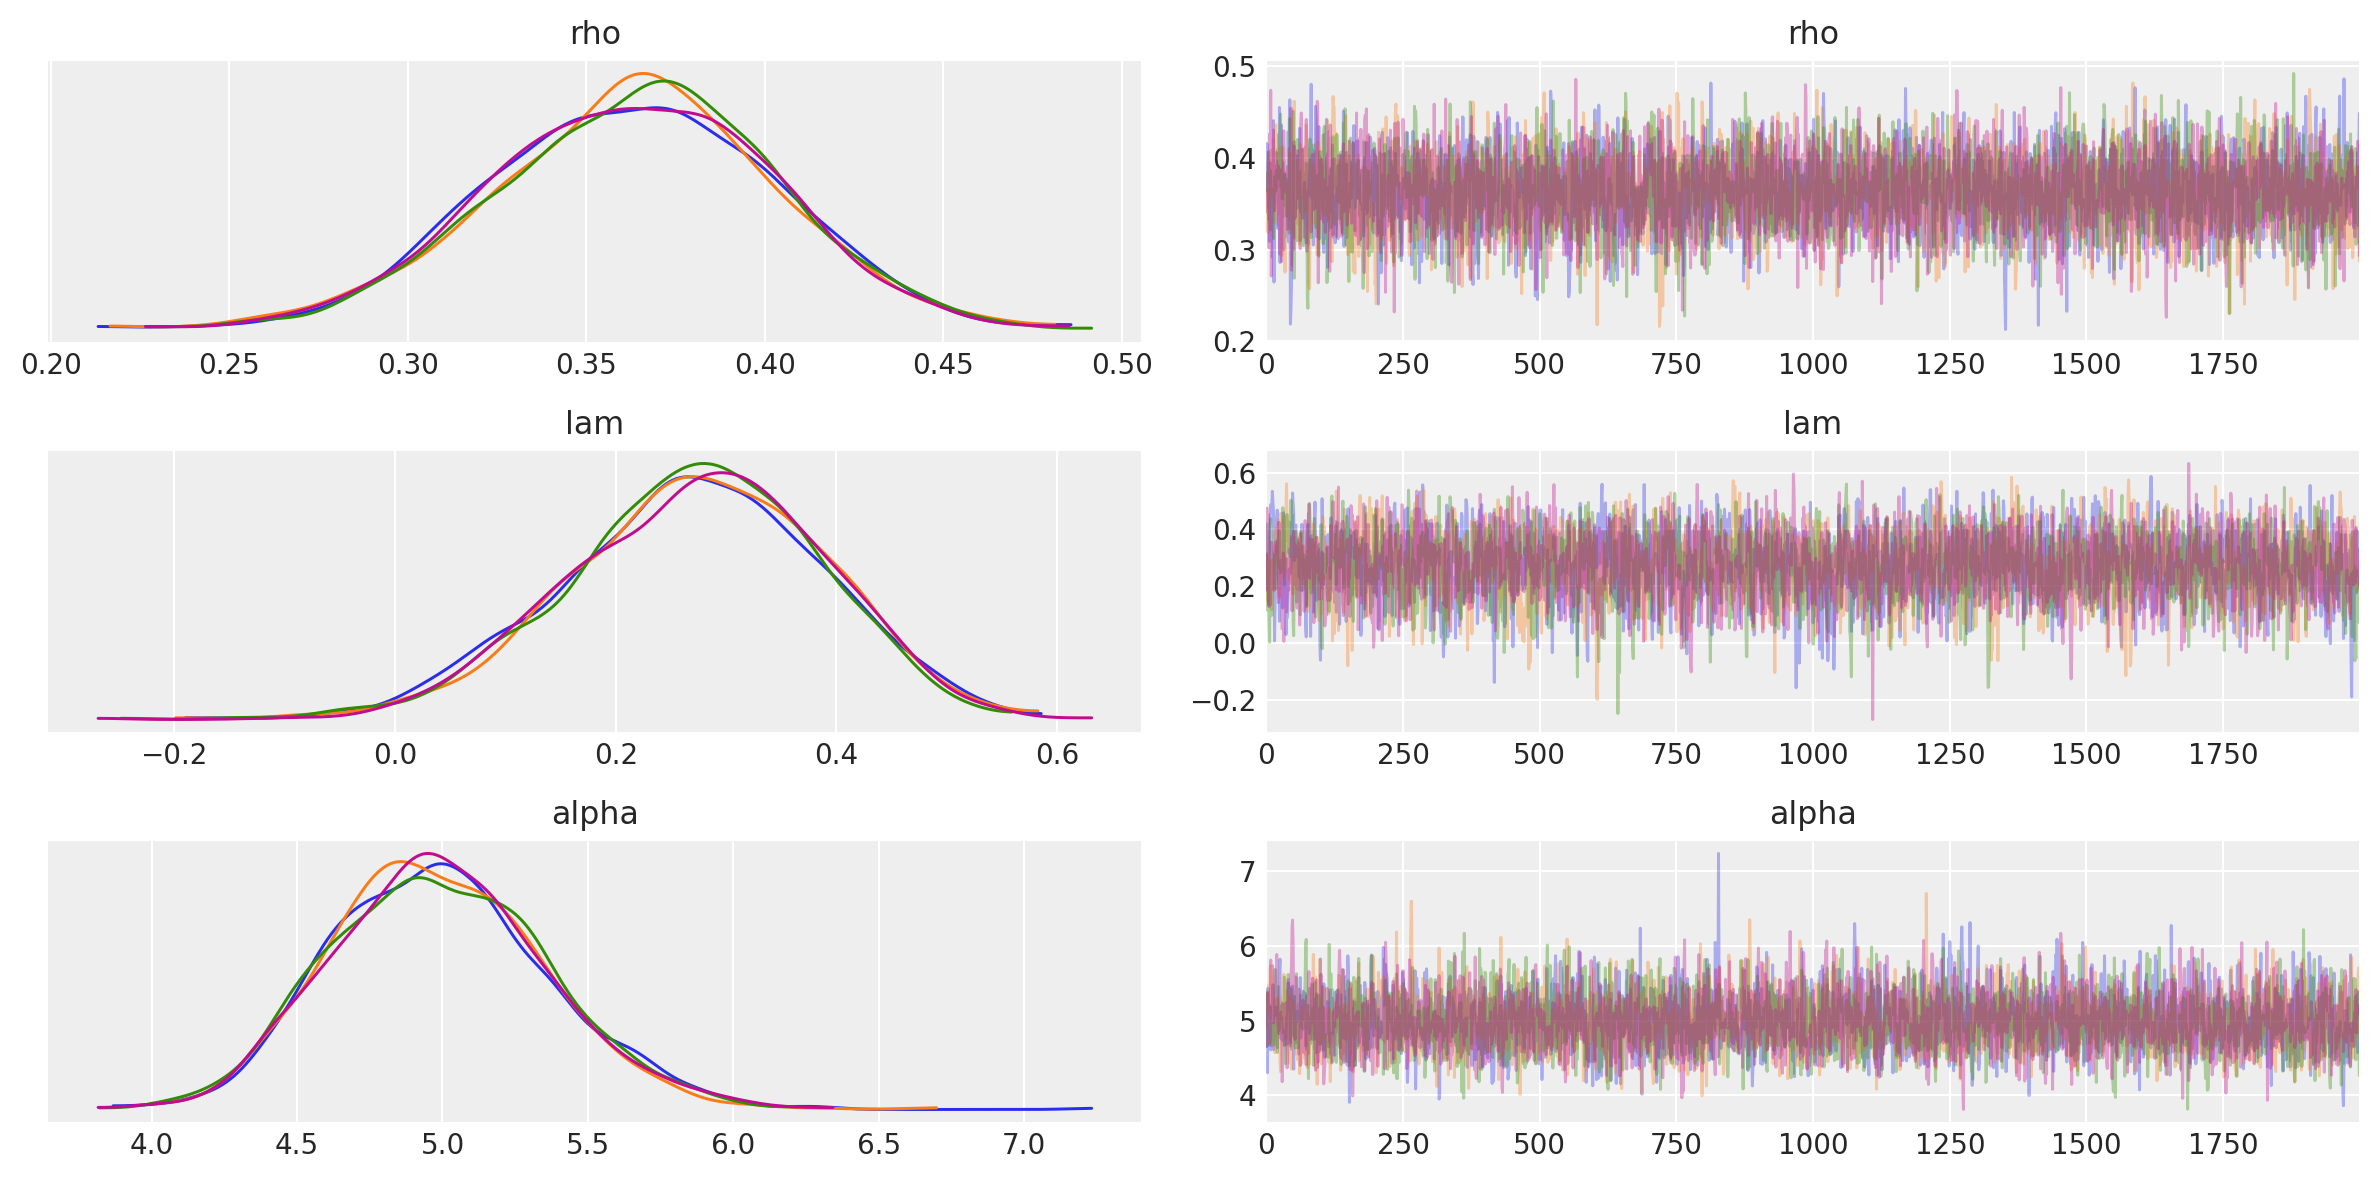

       r_hat  ess_bulk  ess_tail
rho      1.0    6177.0    5855.0
lam      1.0    3526.0    4959.0
alpha    1.0    5015.0    5378.0


In [5]:
# Convergence diagnostics
az.plot_trace(idata, var_names=["rho", "lam", "alpha"], compact=False)
plt.tight_layout()
plt.show()

# R-hat and ESS
diagnostics = az.summary(idata, var_names=["rho", "lam", "alpha"])
print(diagnostics[["r_hat", "ess_bulk", "ess_tail"]])

## Split the zeros between the two processes

The ZINB model decomposes observed zeros into two types:
- **Structural zeros**: the observation is inactive (d=0)
- **Sampling zeros**: the observation is active (d=1) but the NB draw was zero

The `zero_attribution()` method computes the posterior probability of each type for every zero observation.

Number of zero observations: 848

Mean P(structural | y=0): 0.877
Mean P(sampling | y=0):   0.123


/var/folders/j8/5bgcw6hs7cqcbbz48d6bsftw0000gp/T/ipykernel_98446/1143200135.py:19: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


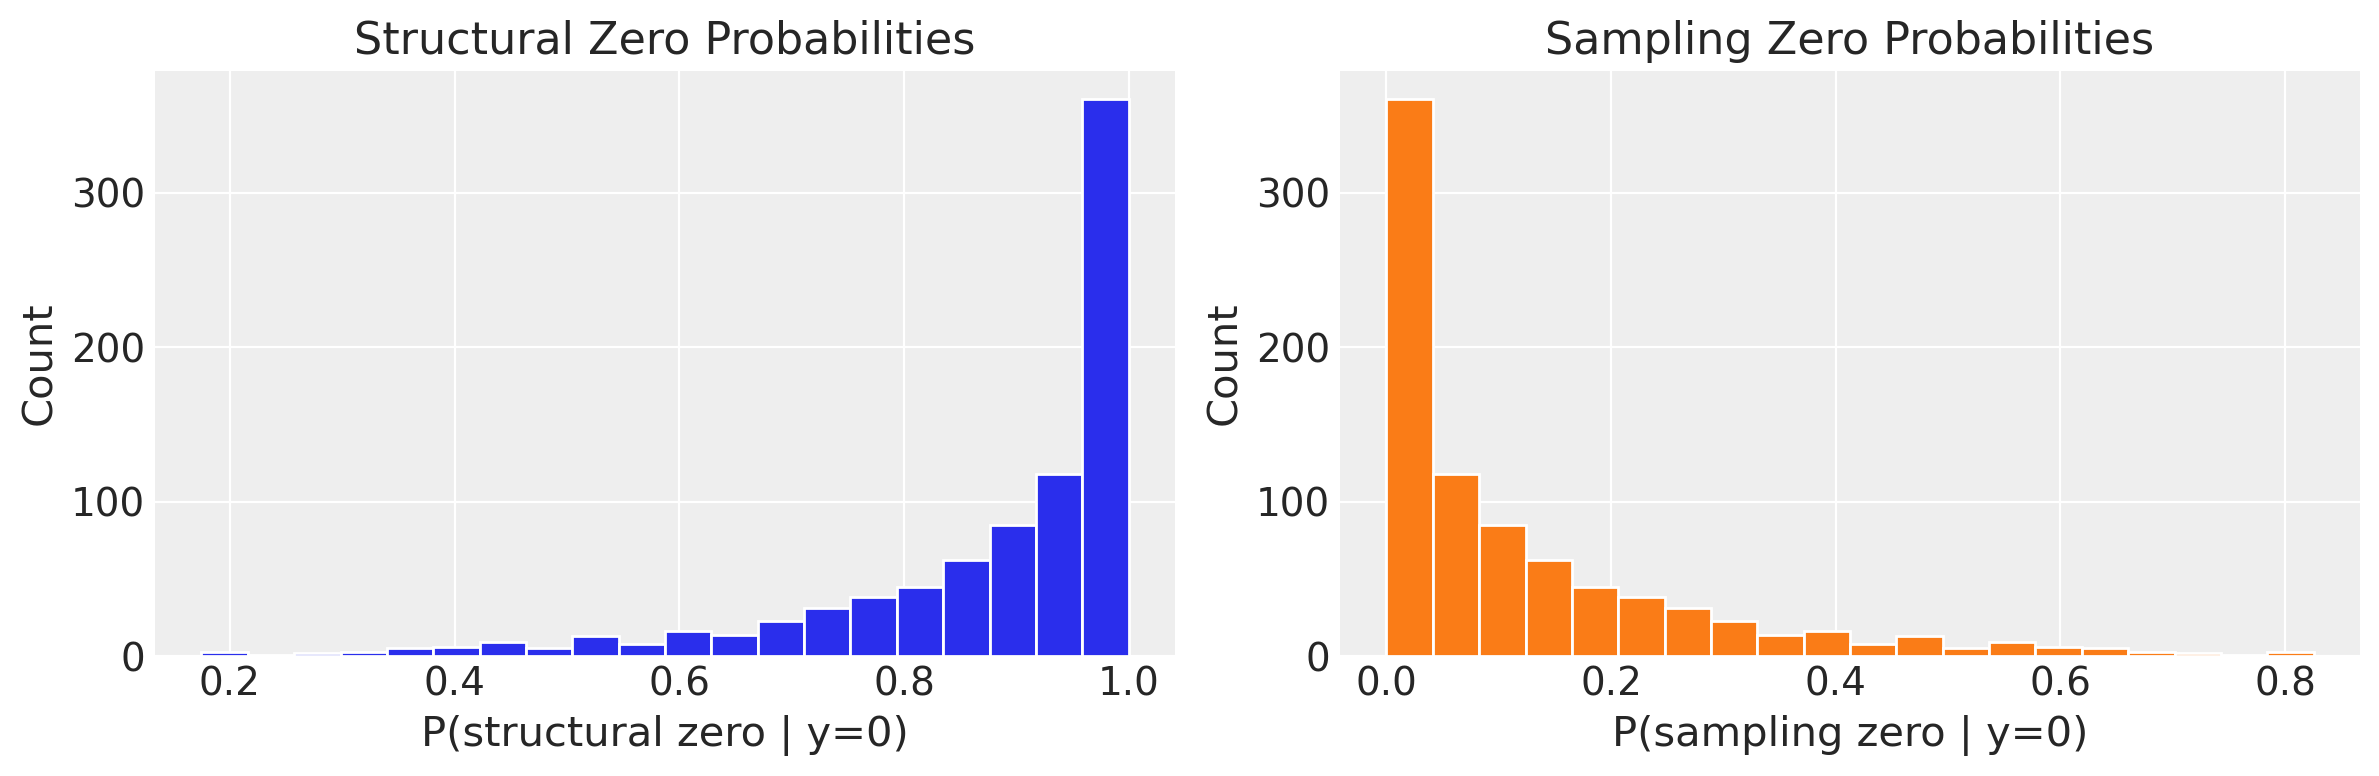

In [6]:
# Zero attribution
attribution = model.zero_attribution()

print(f"Number of zero observations: {len(attribution['zero_indices'])}")
print(f"\nMean P(structural | y=0): {attribution['structural_prob'].mean():.3f}")
print(f"Mean P(sampling | y=0):   {attribution['sampling_prob'].mean():.3f}")

# Histogram of structural zero probabilities
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].hist(attribution["structural_prob"], bins=20, edgecolor="white")
ax[0].set_xlabel("P(structural zero | y=0)")
ax[0].set_ylabel("Count")
ax[0].set_title("Structural Zero Probabilities")

ax[1].hist(attribution["sampling_prob"], bins=20, edgecolor="white", color="C1")
ax[1].set_xlabel("P(sampling zero | y=0)")
ax[1].set_ylabel("Count")
ax[1].set_title("Sampling Zero Probabilities")
plt.tight_layout()
plt.show()

## Get per-observation activation probabilities

The `corridor_probabilities()` method returns the posterior-mean probability that each observation is "active" (i.e., in the count regime rather than the always-zero regime).

Mean corridor probability: 0.703
Min corridor probability:   0.142
Max corridor probability:   0.980

True activation rate: 0.704
Estimated activation rate: 0.703


/var/folders/j8/5bgcw6hs7cqcbbz48d6bsftw0000gp/T/ipykernel_98446/1500508181.py:20: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


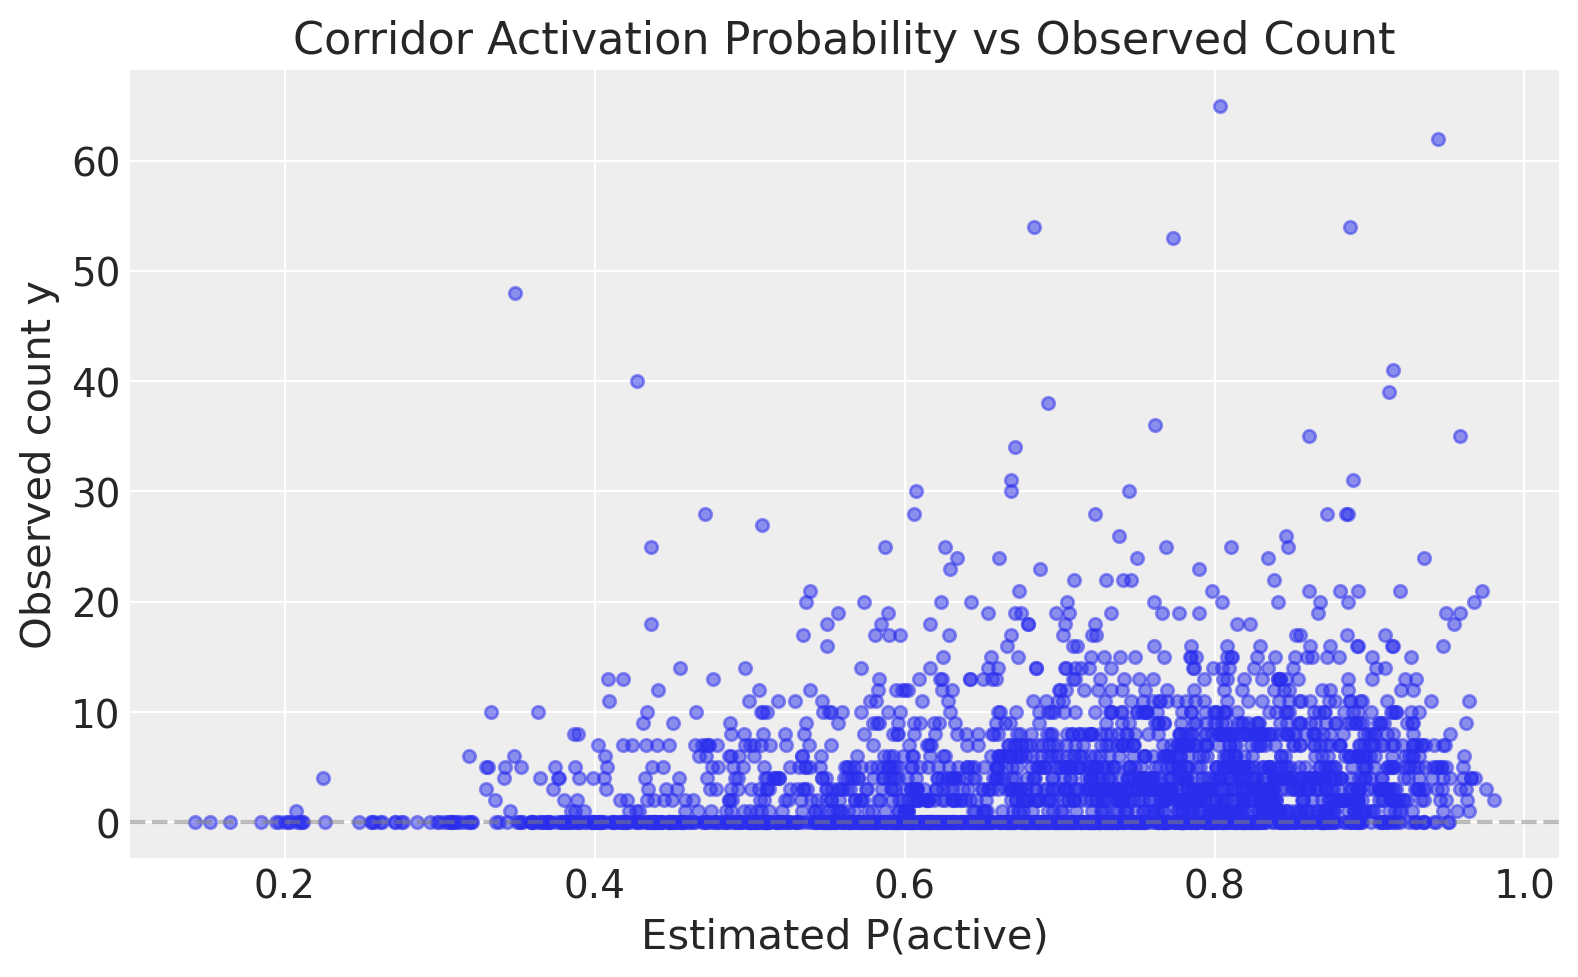

In [7]:
# Corridor activation probabilities
pi = model.corridor_probabilities()

print(f"Mean corridor probability: {pi.mean():.3f}")
print(f"Min corridor probability:   {pi.min():.3f}")
print(f"Max corridor probability:   {pi.max():.3f}")

# Compare with true d
d_true = data["d"]
print(f"\nTrue activation rate: {d_true.mean():.3f}")
print(f"Estimated activation rate: {pi.mean():.3f}")

# Scatter: pi vs observed y
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(pi, y, alpha=0.5, s=20)
ax.set_xlabel("Estimated P(active)")
ax.set_ylabel("Observed count y")
ax.set_title("Corridor Activation Probability vs Observed Count")
ax.axhline(0, color="grey", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

## Predict expected counts

The `fitted_values()` method returns E[y_i] = π_i · exp(η_i^cnt), the posterior-mean expected count for each observation.

Mean fitted count: 4.40
Mean observed count: 4.39


/var/folders/j8/5bgcw6hs7cqcbbz48d6bsftw0000gp/T/ipykernel_98446/1948847008.py:21: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


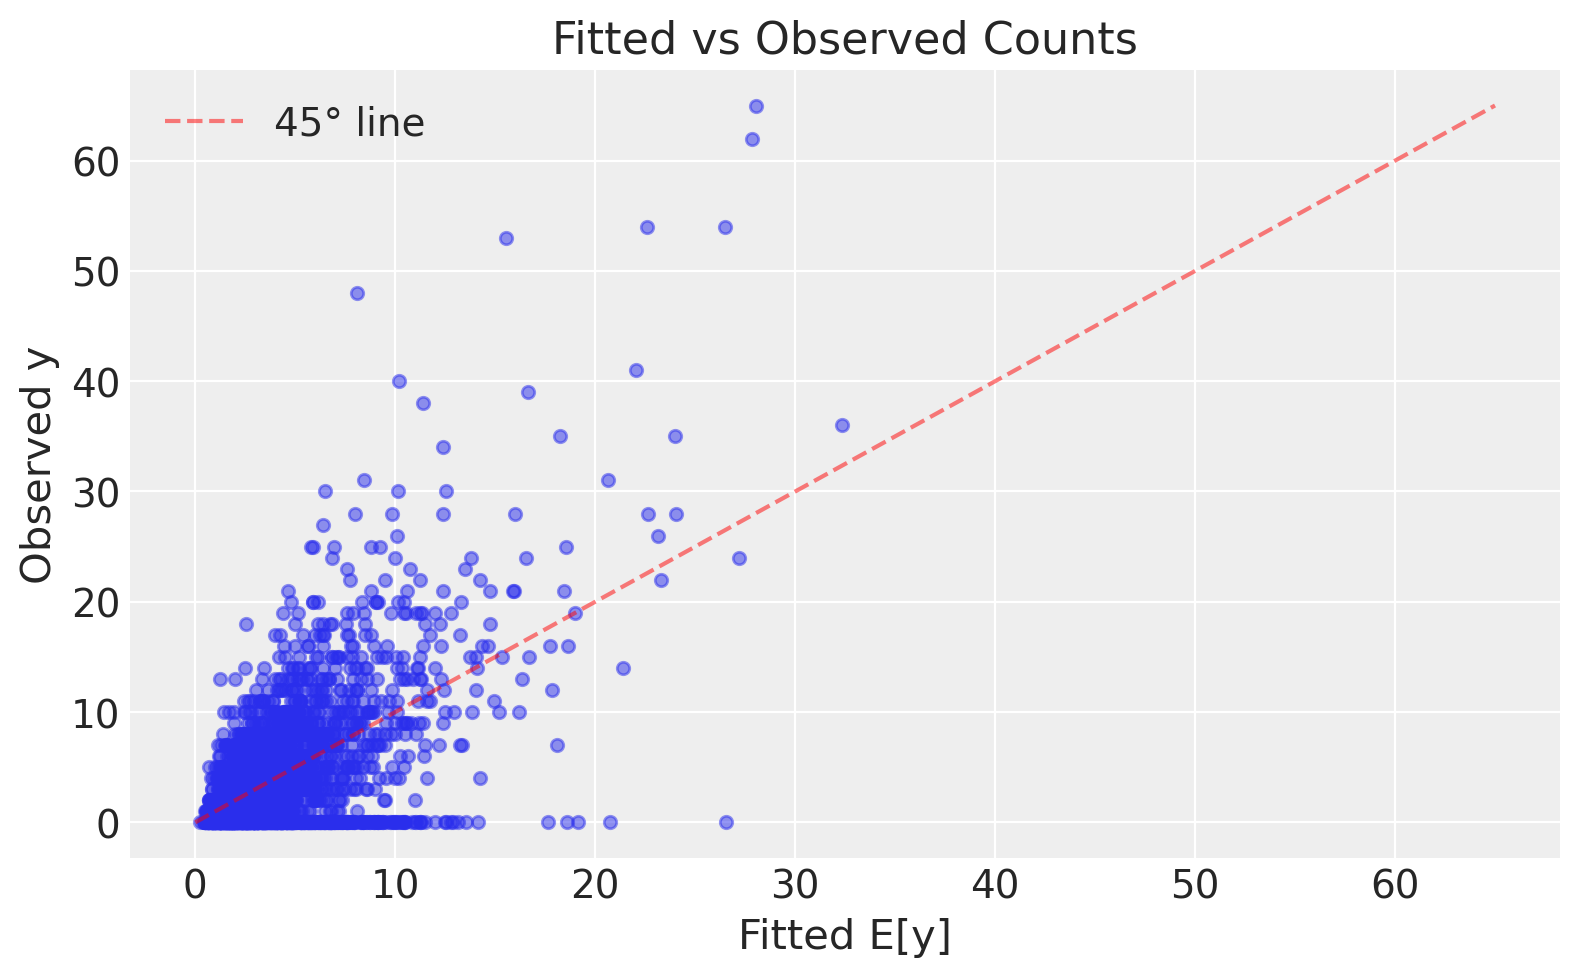

In [8]:
# Fitted mean counts
fitted = model.fitted_values()

print(f"Mean fitted count: {fitted.mean():.2f}")
print(f"Mean observed count: {y.mean():.2f}")

# Scatter: fitted vs observed
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(fitted, y, alpha=0.5, s=20)
ax.plot(
    [0, max(y.max(), fitted.max())],
    [0, max(y.max(), fitted.max())],
    "r--",
    alpha=0.5,
    label="45° line",
)
ax.set_xlabel("Fitted E[y]")
ax.set_ylabel("Observed y")
ax.set_title("Fitted vs Observed Counts")
ax.legend()
plt.tight_layout()
plt.show()

## Inspect the posteriors

Visualize the posterior distributions of the spatial parameters ρ and λ, and the NB dispersion α, with true values marked.

/var/folders/j8/5bgcw6hs7cqcbbz48d6bsftw0000gp/T/ipykernel_98446/297505054.py:22: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


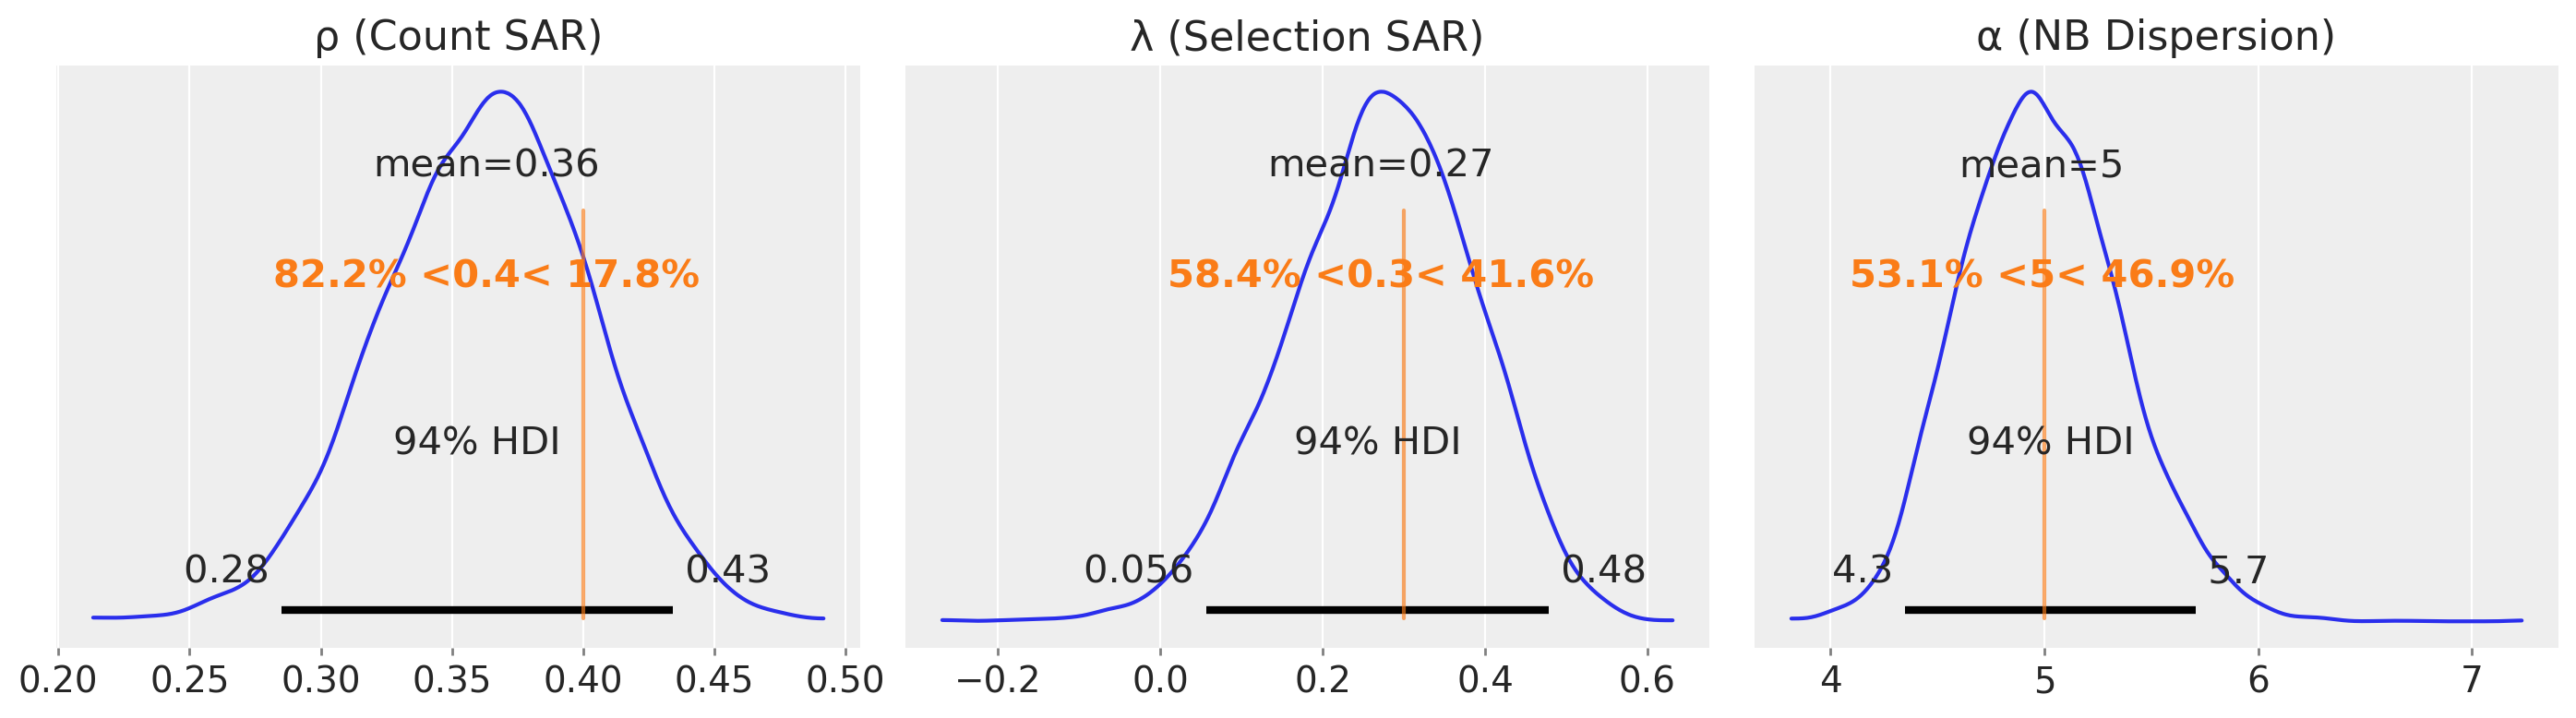

In [9]:
# Posterior distributions with true values
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# ρ (count SAR)
az.plot_posterior(
    idata, var_names=["rho"], ref_val=data["params_true"]["rho"], ax=axes[0]
)
axes[0].set_title("ρ (Count SAR)")

# λ (selection SAR)
az.plot_posterior(
    idata, var_names=["lam"], ref_val=data["params_true"]["lam"], ax=axes[1]
)
axes[1].set_title("λ (Selection SAR)")

# α (NB dispersion)
az.plot_posterior(
    idata, var_names=["alpha"], ref_val=data["params_true"]["alpha"], ax=axes[2]
)
axes[2].set_title("α (NB Dispersion)")

plt.tight_layout()
plt.show()

# Note: spatial parameters (ρ, λ) require large samples (n ≥ 900)
# for reliable recovery in cross-sectional count models. The posterior
# is typically wide and may be attenuated toward zero at moderate n.

## See also

- [How to estimate spatial negative binomial models](negbin_estimation.ipynb) —
  fit this first and compare before assuming zero inflation
- [How to estimate Poisson origin–destination flow models](poisson_flow.ipynb) —
  the flow-data version of the same question
- [Supported Models](../models.md) — `SARZINB` equations and arguments
- [How to set priors](priors.ipynb)